In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Date processing

In [ ]:
df1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Supplement_Sales_Weekly_Expanded.csv")

In [ ]:
df1.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [ ]:
df1.duplicated().sum()

np.int64(0)

In [ ]:
# Convert the Date column to datetime format
df1['Date'] = pd.to_datetime(df1['Date'])

# Create a new column for Week of Month
df1['Week of Month'] = df1['Date'].apply(lambda x: f"Week {((x.day - 1) // 7) + 1}")

# Optional: display result
print(df1[['Date', 'Week of Month']].head())


        Date Week of Month
0 2020-01-06        Week 1
1 2020-01-06        Week 1
2 2020-01-06        Week 1
3 2020-01-06        Week 1
4 2020-01-06        Week 1


In [ ]:
# Convert 'Week of Month' from text to numeric
df1['Week of Month'] = df1['Week of Month'].str.extract('(\d)').astype(int)


In [ ]:
# Convert 'Week of Month' from 'Week 1' to numeric 1, 2, 3, 4
#df1['Week of Month'] = df1['Week of Month'].astype(str).str.extract('(\d)').astype(int)


In [ ]:
#df1['Week of Month'] = df1['Week of Month'].astype(str).str.extract('(\d)').astype(int)


In [ ]:
df1

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Week of Month
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,1
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,1
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,1
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,1
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,1
...,...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb,5
4380,2025-03-31,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart,5
4381,2025-03-31,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb,5
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon,5


In [ ]:
df1_encoded = pd.get_dummies(df1, columns=['Week of Month'], prefix='Week')

In [ ]:
df1_encoded

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Week_1,Week_2,Week_3,Week_4,Week_5
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,True,False,False,False,False
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,True,False,False,False,False
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,True,False,False,False,False
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,True,False,False,False,False
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb,False,False,False,False,True
4380,2025-03-31,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart,False,False,False,False,True
4381,2025-03-31,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb,False,False,False,False,True
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon,False,False,False,False,True


# Subsetting whey protein

In [ ]:
df1=df1_encoded[df1_encoded['Product Name']=='Whey Protein']

In [ ]:
df1.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform', 'Week_1',
       'Week_2', 'Week_3', 'Week_4', 'Week_5'],
      dtype='object')

In [ ]:
df1.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Week_1,Week_2,Week_3,Week_4,Week_5
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,True,False,False,False,False
16,2020-01-13,Whey Protein,Protein,150,12.08,1812.00,0.02,2,UK,Amazon,False,True,False,False,False
32,2020-01-20,Whey Protein,Protein,157,41.81,6564.17,0.19,0,USA,Walmart,False,False,True,False,False
48,2020-01-27,Whey Protein,Protein,137,26.73,3662.01,0.01,0,UK,Amazon,False,False,False,True,False
64,2020-02-03,Whey Protein,Protein,165,33.11,5463.15,0.10,2,Canada,iHerb,True,False,False,False,False


## Creating new variables

In [ ]:
df1 = pd.get_dummies(df1, columns=['Location'])
df1 = pd.get_dummies(df1, columns=['Platform'])
df1=df1.drop(['Location_Canada','Platform_iHerb'],axis=1)


In [ ]:
df1['Discount_amount']=df1['Price']*df1['Discount'] #discount col consists of the discount in percentage of price
df1['Return_rate']=df1['Units Returned']/df1['Units Sold'].replace(0,1)
df1['Effective_Units_Sold']=df1['Units Sold']-df1['Units Returned']
#revenue per unit in a week
df1['Revenue_per_Unit'] = df1['Revenue'] / df1['Units Sold'].replace(0, 1) #replacing 0 with 1 to not divide by 0
df1['Units_Sold_Last_Week'] = df1['Units Sold'].shift(1)
df1['Rolling_Units'] = df1['Units Sold'].rolling(window=3).mean()
pd.set_option('display.max_columns', None)

In [ ]:
df1=df1.dropna()


In [ ]:
df_training=df1.drop(['Date','Product Name','Category'],axis=1)
df_training=df_training.astype(float)
df_training.head(2)

,Units Sold,Price,Revenue,Discount,Units Returned,Week_1,Week_2,Week_3,Week_4,Week_5,Location_UK,Location_USA,Platform_Amazon,Platform_Walmart,Discount_amount,Return_rate,Effective_Units_Sold,Revenue_per_Unit,Units_Sold_Last_Week,Rolling_Units
32,157.0,41.81,6564.17,0.19,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,7.9439,0.0,157.0,41.81,150.0,150.0
48,137.0,26.73,3662.01,0.01,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.2673,0.0,137.0,26.73,157.0,148.0


# Creating a lags

In [ ]:
lag_cols = ['Units Sold', 'Price', 'Revenue', 'Discount']
for col in lag_cols:
    for i in range(1, 4):
        df_training[f'{col}_lag_{i}'] = df_training[col].shift(i)
print(f'{i} lags')


3 lags


In [ ]:
df_training=df_training.dropna()

# Finding optimal network

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_training.drop(columns=['Units Sold'])  # input features
y = df_training['Units Sold']                 # target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scale inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
from keras_tuner import RandomSearch

def build_model(hp):
    model = Sequential()
    # Input layer
    model.add(Dense(hp.Int('units_input', 32, 128, step=16), activation='relu', input_shape=(X_train_scaled.shape[1],)))

    # Hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(hp.Int(f'units_{i}', 16, 128, step=16), activation='relu'))

    # Output
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(
                      hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
                  loss='mse',
                  metrics=['mae'])
    return model

tuner = RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=10,
    executions_per_trial=2,
    directory='ann_units_tuner',
    project_name='units_sold_prediction'
)

tuner.search(X_train_scaled, y_train, epochs=100, validation_split=0.2)


Trial 10 Complete [00h 00m 38s]
val_mae: 16.54411029815674

Best val_mae So Far: 16.273160934448242
Total elapsed time: 00h 06m 33s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.evaluate(X_test_scaled, y_test)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 305.3855 - mae: 13.5438 


[337.6949462890625, 14.338738441467285]

In [ ]:
y_pred = best_model.predict(X_test_scaled)
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred.flatten(), label='Predicted')
plt.legend()
plt.show()


In [ ]:
from keras_tuner import RandomSearch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input
import tensorflow as tf
from tqdm import tqdm

# Epoch values to test
epoch_list = [10, 25, 50, 75, 100]
results = []

# Build model function
def build_model(hp):
    model = Sequential()
    activation = hp.Choice('activation', ['relu', 'tanh'])

    model.add(Input(shape=(X_train_scaled.shape[1],)))
    model.add(Dense(hp.Int('units_input', 32, 128, step=16), activation=activation))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(hp.Int(f'units_{i}', 16, 128, step=16), activation=activation))

    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
        loss='mse',
        metrics=['mae']
    )
    return model

# Loop through each epoch count
for ep in tqdm(epoch_list, desc="Epoch Variation Test"):
    tuner = RandomSearch(
        build_model,
        objective='val_mae',
        max_trials=3,  # reduce for quick testing
        executions_per_trial=1,
        directory='epoch_tune_dir',
        project_name=f'epochs_{ep}'
    )

    tuner.search(X_train_scaled, y_train, epochs=ep, validation_split=0.2, verbose=0)

    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
    best_val_mae = best_trial.metrics.get_last_value('val_mae')

    results.append({
        'epochs': ep,
        'val_mae': best_val_mae,
        'activation': best_hp.get('activation'),
        'units_input': best_hp.get('units_input'),
        'num_layers': best_hp.get('num_layers'),
        'learning_rate': best_hp.get('learning_rate'),
    })

# Show results
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results.sort_values('val_mae'))


Epoch Variation Test:   0%|          | 0/5 [00:00<?, ?it/s]

Reloading Tuner from epoch_tune_dir/epochs_10/tuner0.json


Epoch Variation Test: 100%|██████████| 5/5 [02:56<00:00, 35.37s/it]

   epochs    val_mae activation  units_input  num_layers  learning_rate
0      10  14.002810       relu           96           3       0.003918
2      50  14.387718       relu           80           2       0.002522
4     100  14.538429       tanh           32           1       0.003534
3      75  16.855276       relu          112           2       0.000316
1      25  19.473301       relu           96           3       0.000611


In [ ]:
df_results

,epochs,val_mae,activation,units_input,num_layers,learning_rate
0,10,14.002810,relu,96,3,0.003918
1,25,19.473301,relu,96,3,0.000611
2,50,14.387718,relu,80,2,0.002522
3,75,16.855276,relu,112,2,0.000316
4,100,14.538429,tanh,32,1,0.003534


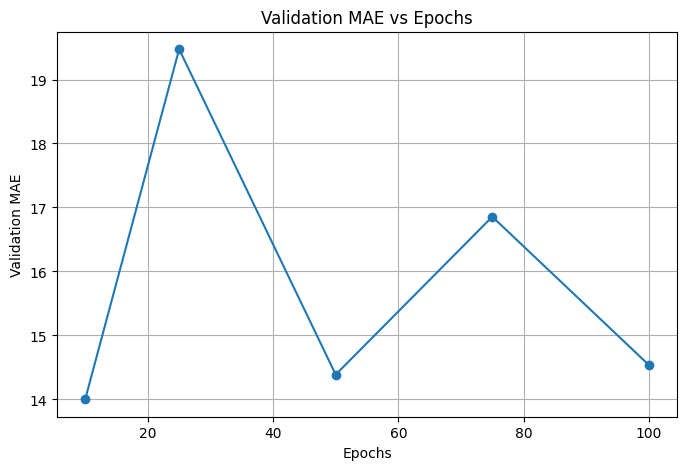

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_results['epochs'], df_results['val_mae'], marker='o')
plt.title('Validation MAE vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.grid(True)
plt.show()


# Using Standard Scaler - learning rate 0.0039

Walk-Forward Progress: 100%|██████████| 54/54 [03:15<00:00,  3.62s/it]


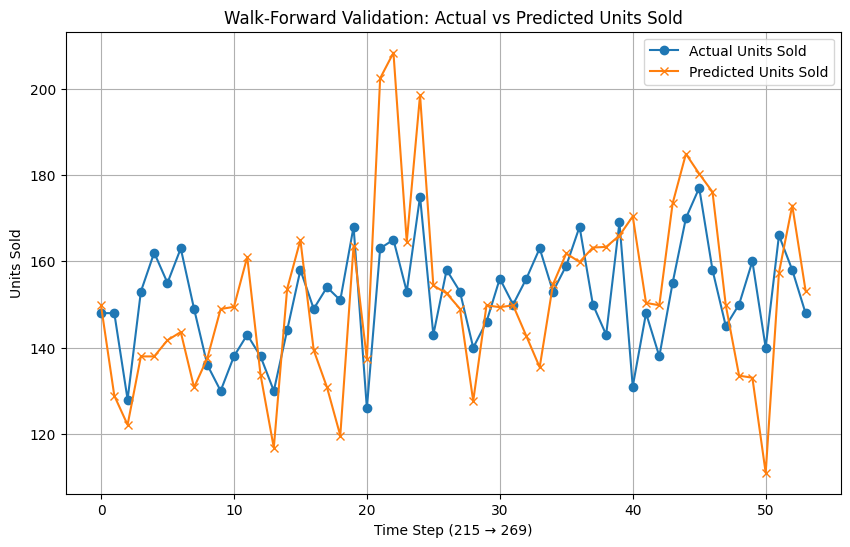

In [ ]:
from tqdm import tqdm  # <-- Add this at the top
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input
import tensorflow as tf

# Prepare input and output
X = df_training.drop(columns=['Units Sold'])
y = df_training['Units Sold'].values

# Initialize scaler
scaler = StandardScaler()

# Start walk-forward loop
history_size = round(len(df_training)*0.8)
predictions = []
actuals = []


for i in tqdm(range(history_size, len(X)), desc="Walk-Forward Progress"):
    X_train = X.iloc[:i]
    y_train = y[:i]
    X_test = X.iloc[i:i+1]
    y_test = y[i]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='relu'),
        Dense(32, activation='relu'),
        Dense(80, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0039),
                  loss='mse',
                  metrics=['mae'])

    model.fit(X_train_scaled, y_train, epochs=10, batch_size=16, verbose=0)

    pred = model.predict(X_test_scaled, verbose=0)[0][0]
    predictions.append(pred)
    actuals.append(y_test)


# Plot predicted vs actual
plt.figure(figsize=(10,6))
plt.plot(actuals, label='Actual Units Sold', marker='o')
plt.plot(predictions, label='Predicted Units Sold', marker='x')
plt.title('Walk-Forward Validation: Actual vs Predicted Units Sold')
plt.xlabel(f'Time Step ({round(len(df_training)*0.8)} → {round(len(df_training))})')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()


Walk-Forward Progress: 100%|██████████| 54/54 [07:38<00:00,  8.48s/it]


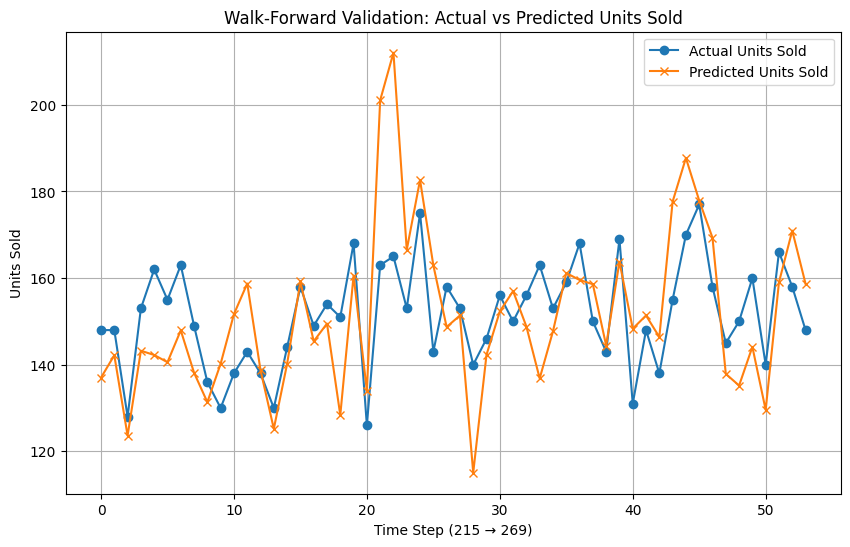

In [ ]:
from tqdm import tqdm  # <-- Add this at the top
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input
import tensorflow as tf

# Prepare input and output
X = df_training.drop(columns=['Units Sold'])
y = df_training['Units Sold'].values

# Initialize scaler
scaler = StandardScaler()

# Start walk-forward loop
history_size = round(len(df_training)*0.8)
predictions = []
actuals = []


for i in tqdm(range(history_size, len(X)), desc="Walk-Forward Progress"):
    X_train = X.iloc[:i]
    y_train = y[:i]
    X_test = X.iloc[i:i+1]
    y_test = y[i]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='relu'),
        Dense(32, activation='relu'),
        Dense(80, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0039),
                  loss='mse',
                  metrics=['mae'])

    model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, verbose=0)

    pred = model.predict(X_test_scaled, verbose=0)[0][0]
    predictions.append(pred)
    actuals.append(y_test)


# Plot predicted vs actual
plt.figure(figsize=(10,6))
plt.plot(actuals, label='Actual Units Sold', marker='o')
plt.plot(predictions, label='Predicted Units Sold', marker='x')
plt.title('Walk-Forward Validation: Actual vs Predicted Units Sold')
plt.xlabel(f'Time Step ({round(len(df_training)*0.8)} → {round(len(df_training))})')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()


# MinMax Scaler - learning rate 0.0039

Walk-Forward Progress: 100%|██████████| 54/54 [03:14<00:00,  3.61s/it]


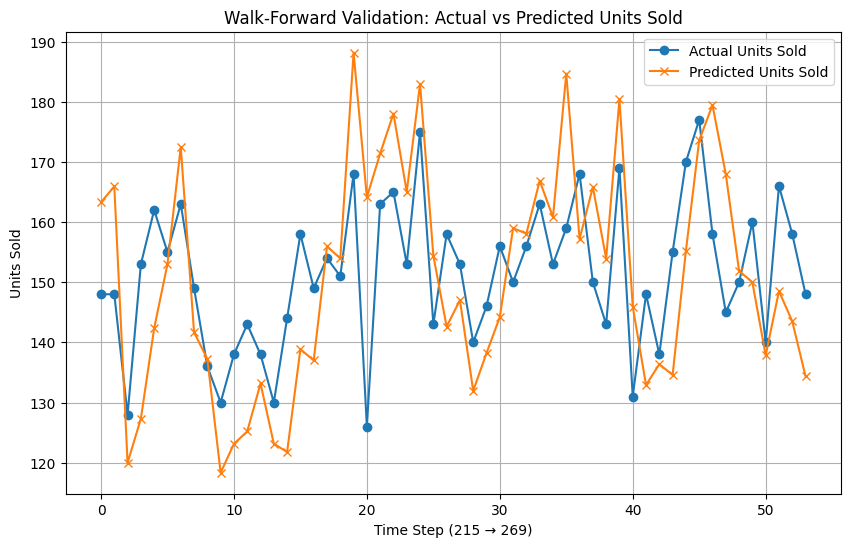

In [ ]:
from tqdm import tqdm  # <-- Add this at the top
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from tensorflow.keras import Input

# Prepare input and output
X = df_training.drop(columns=['Units Sold'])
y = df_training['Units Sold'].values

# Initialize scaler
scaler = MinMaxScaler()

# Start walk-forward loop
history_size = round(len(df_training)*0.8)
predictions = []
actuals = []


for i in tqdm(range(history_size, len(X)), desc="Walk-Forward Progress"):
    X_train = X.iloc[:i]
    y_train = y[:i]
    X_test = X.iloc[i:i+1]
    y_test = y[i]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='relu'),
        Dense(32, activation='relu'),
        Dense(80, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0039),
                  loss='mse',
                  metrics=['mae'])

    model.fit(X_train_scaled, y_train, epochs=10, batch_size=16, verbose=0)

    pred = model.predict(X_test_scaled, verbose=0)[0][0]
    predictions.append(pred)
    actuals.append(y_test)


# Plot predicted vs actual
plt.figure(figsize=(10,6))
plt.plot(actuals, label='Actual Units Sold', marker='o')
plt.plot(predictions, label='Predicted Units Sold', marker='x')
plt.title('Walk-Forward Validation: Actual vs Predicted Units Sold')
plt.xlabel(f'Time Step ({round(len(df_training)*0.8)} → {round(len(df_training))})')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()


# Using MinMax Scaler - epochs 10



Walk-Forward Progress: 100%|██████████| 54/54 [07:37<00:00,  8.47s/it]


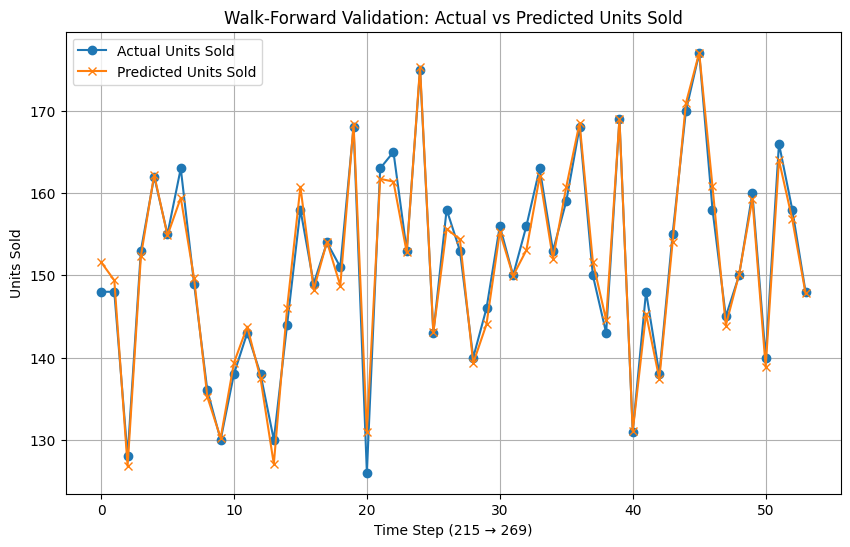

In [ ]:
from tqdm import tqdm  # <-- Add this at the top
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from tensorflow.keras import Input

# Prepare input and output
X = df_training.drop(columns=['Units Sold'])
y = df_training['Units Sold'].values

# Initialize scaler
scaler = MinMaxScaler()

# Start walk-forward loop
history_size = round(len(df_training)*0.8)
predictions = []
actuals = []


for i in tqdm(range(history_size, len(X)), desc="Walk-Forward Progress"):
    X_train = X.iloc[:i]
    y_train = y[:i]
    X_test = X.iloc[i:i+1]
    y_test = y[i]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='relu'),
        Dense(32, activation='relu'),
        Dense(80, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0039),
                  loss='mse',
                  metrics=['mae'])

    model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, verbose=0)

    pred = model.predict(X_test_scaled, verbose=0)[0][0]
    predictions.append(pred)
    actuals.append(y_test)


# Plot predicted vs actual
plt.figure(figsize=(10,6))
plt.plot(actuals, label='Actual Units Sold', marker='o')
plt.plot(predictions, label='Predicted Units Sold', marker='x')
plt.title('Walk-Forward Validation: Actual vs Predicted Units Sold')
plt.xlabel(f'Time Step ({round(len(df_training)*0.8)} → {round(len(df_training))})')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()


# MinMax Scaler - epochs 50

Walk-Forward Progress: 100%|██████████| 54/54 [07:43<00:00,  8.57s/it]


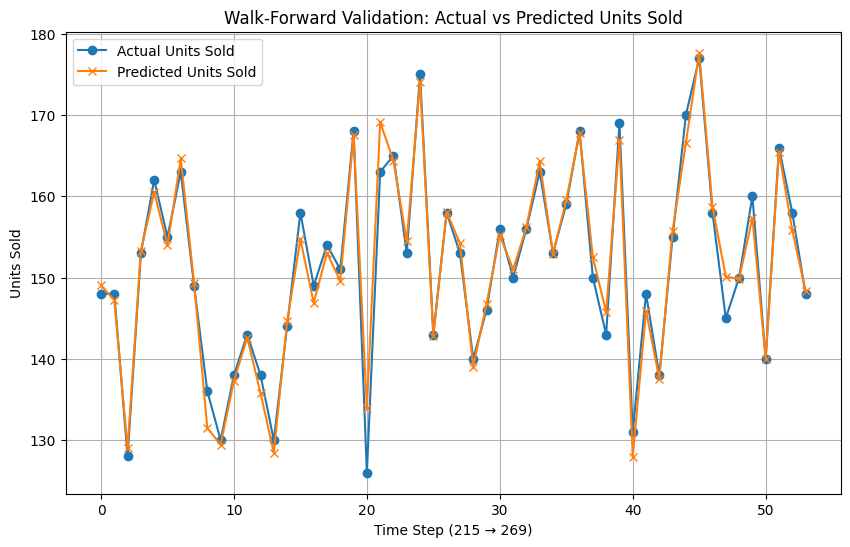

In [ ]:
from tqdm import tqdm  # <-- Add this at the top
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from tensorflow.keras import Input

# Prepare input and output
X = df_training.drop(columns=['Units Sold'])
y = df_training['Units Sold'].values

# Initialize scaler
scaler = MinMaxScaler()

# Start walk-forward loop
history_size = round(len(df_training)*0.8)
predictions = []
actuals = []


for i in tqdm(range(history_size, len(X)), desc="Walk-Forward Progress"):
    X_train = X.iloc[:i]
    y_train = y[:i]
    X_test = X.iloc[i:i+1]
    y_test = y[i]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation='relu'),
        Dense(32, activation='relu'),
        Dense(80, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0039),
                  loss='mse',
                  metrics=['mae'])

    model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, verbose=0)

    pred = model.predict(X_test_scaled, verbose=0)[0][0]
    predictions.append(pred)
    actuals.append(y_test)


# Plot predicted vs actual
plt.figure(figsize=(10,6))
plt.plot(actuals, label='Actual Units Sold', marker='o')
plt.plot(predictions, label='Predicted Units Sold', marker='x')
plt.title('Walk-Forward Validation: Actual vs Predicted Units Sold')
plt.xlabel(f'Time Step ({round(len(df_training)*0.8)} → {round(len(df_training))})')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()
